# 🧠 Mental Health Intelligence Platform

## Phase 4 — Exploratory Data Analysis

### Overview

Understanding workplace policies alone is insufficient for improving employee well-being.

This notebook focuses on the mental health experiences of survey respondents and investigates the factors associated with treatment-seeking behavior, workplace disclosure, and perceived support.

The insights generated here form the analytical foundation for later statistical testing and predictive modeling.

---

### Objectives

The objectives of this notebook are:

- Explore treatment-seeking behaviour
- Examine diagnosed mental health disorders
- Investigate family history
- Measure workplace interference
- Understand disclosure behaviour
- Evaluate workplace support

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../../data/processed/harmonized_osmi_data.csv")

print(df.shape)

df.head()

(3082, 70)


,source_file,survey_year,self_employed,no_employees,tech_company,primary_role_tech,benefits,know_options,formal_discussion,resources,anonymity,leave_ease,comfort_physical_mental,comfort_supervisor,discussed_with_employer,comfort_coworkers,discussed_with_coworkers,coworker_discussed_with_you,employer_importance_physical,employer_importance_mental,coverage_mental_health,know_resources,reveal_to_clients,reveal_to_coworkers,productivity_affected,productivity_percent_affected,have_prev_employers,prev_tech_company,prev_benefits,prev_know_options,prev_formal_discussion,prev_resources,prev_anonymity,prev_comfort_physical_mental,prev_comfort_supervisor,prev_discussed_with_employer,prev_comfort_coworkers,prev_discussed_with_coworkers,prev_employer_importance_physical,prev_employer_importance_mental,currently_disordered,diagnosed_disorder,past_disorder,sought_treatment,family_history,interference_when_treated,interference_when_not_treated,observations_less_likely_reveal,share_with_friends_family,bring_up_physical_interview,bring_up_mental_interview,bring_up_mental_why,openly_identified,identified_affected_career,identified_affected_how,team_reaction_if_knew,observed_unsupportive_response,unsupportive_response_desc,observed_supportive_response,industry_support_rating,improvement_suggestions,additional_comments,willing_to_interview,age,gender,country_live,state_live,race,country_work,state_work
0,2014,2014,NaN,2025-06-01 00:00:00,Yes,NaN,Yes,Don't Know,No,Yes,Yes,Somewhat easy,Yes,Yes,No,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Often,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN
1,2014,2014,NaN,More than 1000,No,NaN,Don't Know,No,Don't Know,Don't Know,Don't Know,Don't Know,Don't know,No,Maybe,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Rarely,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
2,2014,2014,NaN,2025-06-01 00:00:00,Yes,NaN,No,No,No,No,Don't Know,Somewhat difficult,No,Yes,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Rarely,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
3,2014,2014,NaN,26-100,Yes,NaN,No,Yes,No,No,No,Somewhat difficult,No,No,Yes,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,Often,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
4,2014,2014,NaN,100-500,Yes,NaN,Yes,No,Don't Know,Don't Know,Don't Know,Don't Know,Don't know,Yes,No,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Never,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN


## Treatment Seeking Behaviour

Seeking professional treatment represents one of the most important outcomes within this survey.

Understanding the proportion of respondents who have sought treatment provides an initial overview of mental health support utilization.

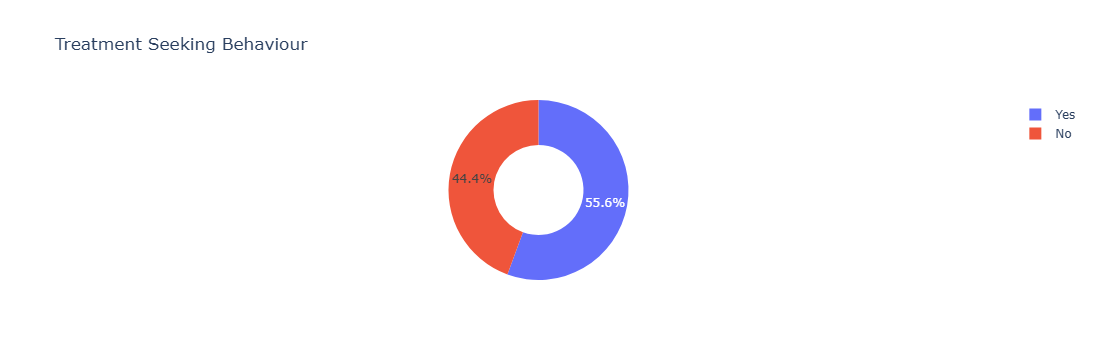

In [3]:
treatment = (
    df["sought_treatment"]
    .value_counts(dropna=False)
    .reset_index()
)

treatment.columns = [
    "Treatment",
    "Count"
]

fig = px.pie(
    treatment,
    names="Treatment",
    values="Count",
    hole=.5,
    title="Treatment Seeking Behaviour"
)

fig.show()

## Family History of Mental Illness

Family history is widely recognized as an important risk factor for mental health disorders.

This section examines the prevalence of reported family history among respondents.

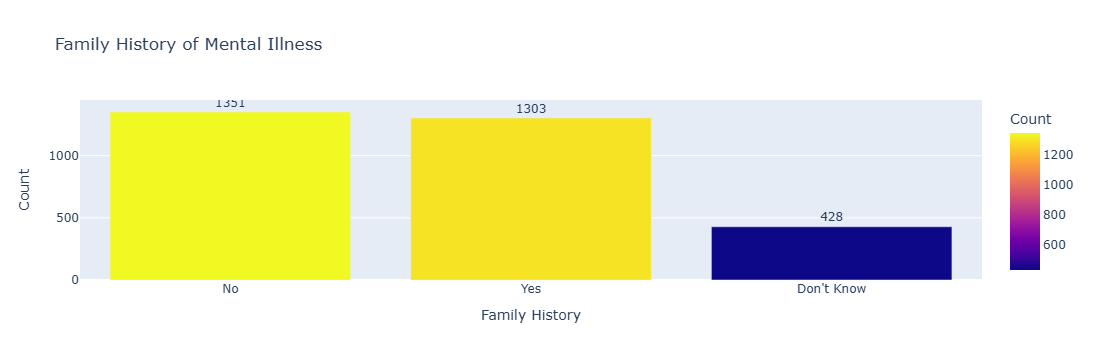

In [4]:
family = (
    df["family_history"]
    .value_counts(dropna=False)
    .reset_index()
)

family.columns = [
    "Family History",
    "Count"
]

fig = px.bar(
    family,
    x="Family History",
    y="Count",
    color="Count",
    text="Count",
    title="Family History of Mental Illness"
)

fig.update_traces(textposition="outside")

fig.show()

## Diagnosed Mental Health Disorders

This section examines how many respondents report receiving a formal mental health diagnosis from a healthcare professional.

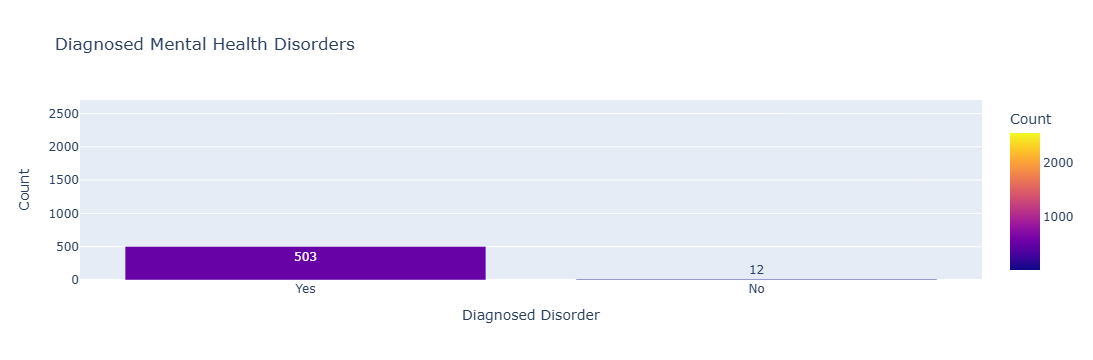

In [5]:
diag = (
    df["diagnosed_disorder"]
    .value_counts(dropna=False)
    .reset_index()
)

diag.columns = [
    "Diagnosed Disorder",
    "Count"
]

fig = px.bar(
    diag,
    x="Diagnosed Disorder",
    y="Count",
    color="Count",
    text="Count",
    title="Diagnosed Mental Health Disorders"
)

fig.show()

## Current Mental Health Status

Respondents were asked whether they currently experience a mental health disorder.

Understanding the prevalence of current disorders provides valuable context for interpreting workplace experiences.

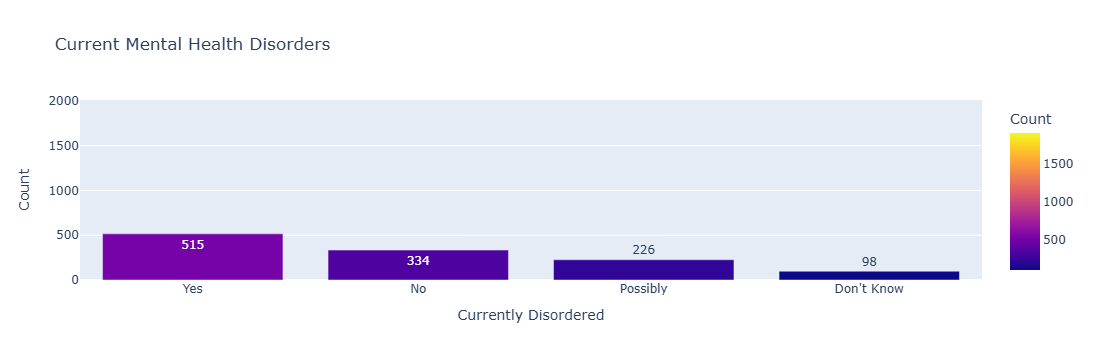

In [7]:
current = (
    df["currently_disordered"]
    .value_counts(dropna=False)
    .reset_index()
)

current.columns = [
    "Currently Disordered",
    "Count"
]

fig = px.bar(
    current,
    x="Currently Disordered",
    y="Count",
    color="Count",
    text="Count",
    title="Current Mental Health Disorders"
)

fig.show()

## Interference with Work Performance

Mental health conditions can influence workplace productivity.

This section examines how respondents perceive the impact of mental health on their daily work.

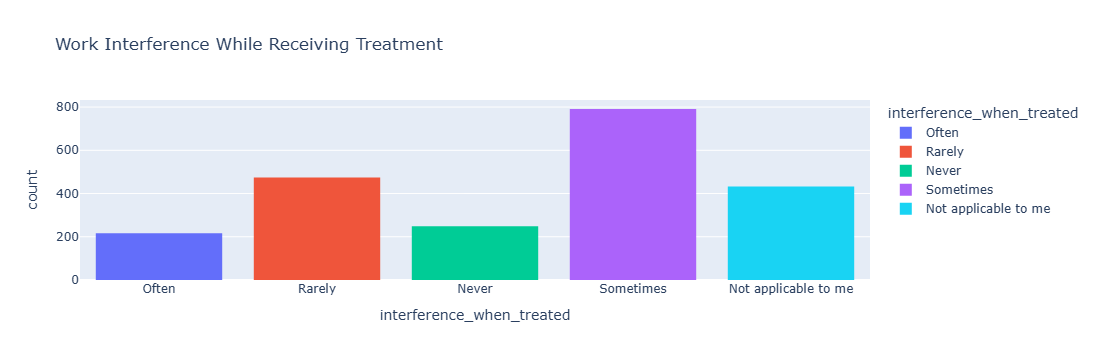

In [9]:
fig = px.histogram(
    df,
    x="interference_when_treated",
    color="interference_when_treated",
    title="Work Interference While Receiving Treatment"
)

fig.show()

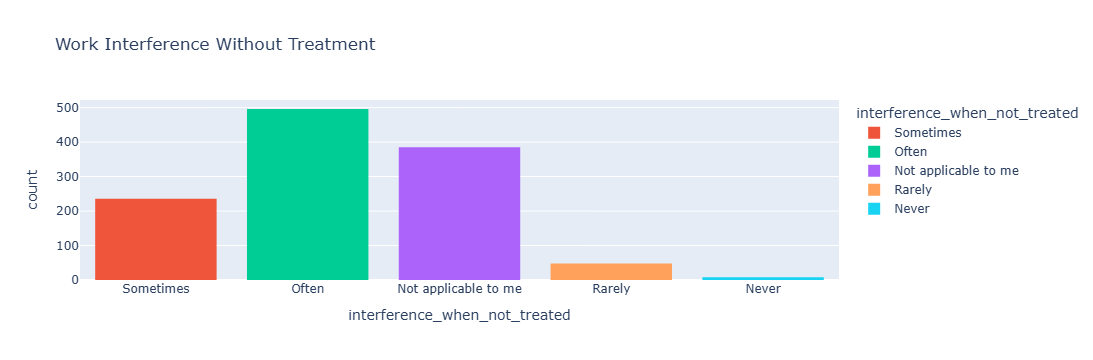

In [10]:
fig = px.histogram(
    df,
    x="interference_when_not_treated",
    color="interference_when_not_treated",
    title="Work Interference Without Treatment"
)

fig.show()

## Comfort Discussing Mental Health

Open communication regarding mental health is an important indicator of workplace psychological safety.

This section explores how comfortable respondents feel discussing mental health with supervisors and coworkers.

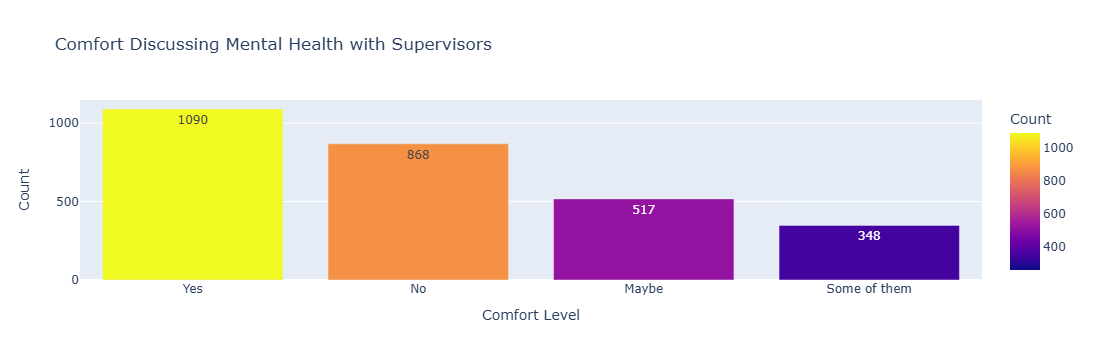

In [12]:
comfort = (
    df["comfort_supervisor"]
    .value_counts(dropna=False)
    .reset_index()
)

comfort.columns = [
    "Comfort Level",
    "Count"
]

fig = px.bar(
    comfort,
    x="Comfort Level",
    y="Count",
    color="Count",
    text="Count",
    title="Comfort Discussing Mental Health with Supervisors"
)

fig.show()

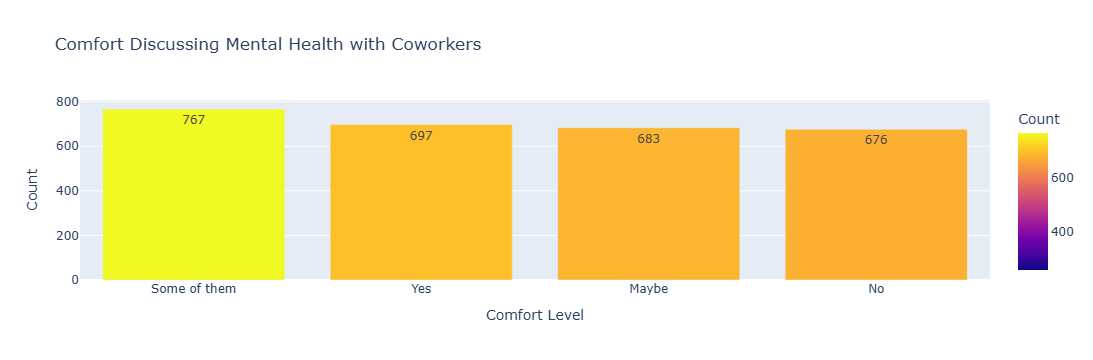

In [13]:
coworker = (
    df["comfort_coworkers"]
    .value_counts(dropna=False)
    .reset_index()
)

coworker.columns = [
    "Comfort Level",
    "Count"
]

fig = px.bar(
    coworker,
    x="Comfort Level",
    y="Count",
    color="Count",
    text="Count",
    title="Comfort Discussing Mental Health with Coworkers"
)

fig.show()

## Mental Health Disclosure

Disclosure of mental health conditions remains a sensitive workplace issue.

This section investigates whether respondents openly identify or reveal their mental health conditions.

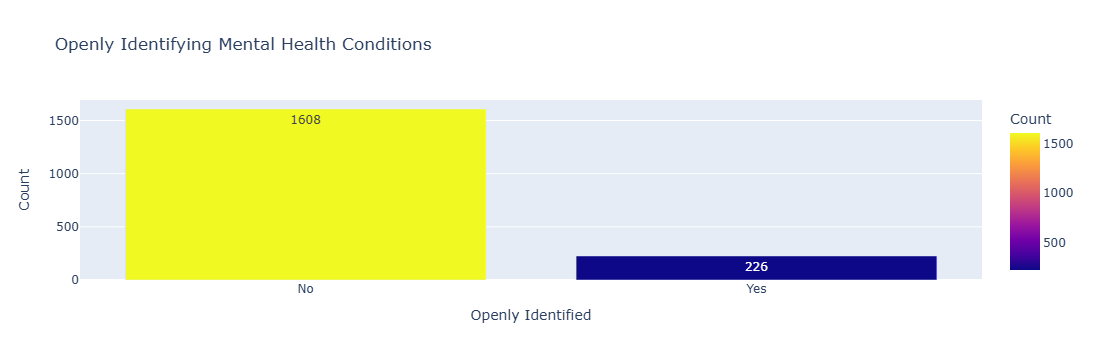

In [15]:
disclosure = (
    df["openly_identified"]
    .value_counts(dropna=False)
    .reset_index()
)

disclosure.columns = [
    "Openly Identified",
    "Count"
]

fig = px.bar(
    disclosure,
    x="Openly Identified",
    y="Count",
    color="Count",
    text="Count",
    title="Openly Identifying Mental Health Conditions"
)

fig.show()

## Family History vs Treatment Seeking

Family history is often associated with increased awareness of mental health conditions.

This section investigates whether respondents with a family history are more likely to seek professional treatment.

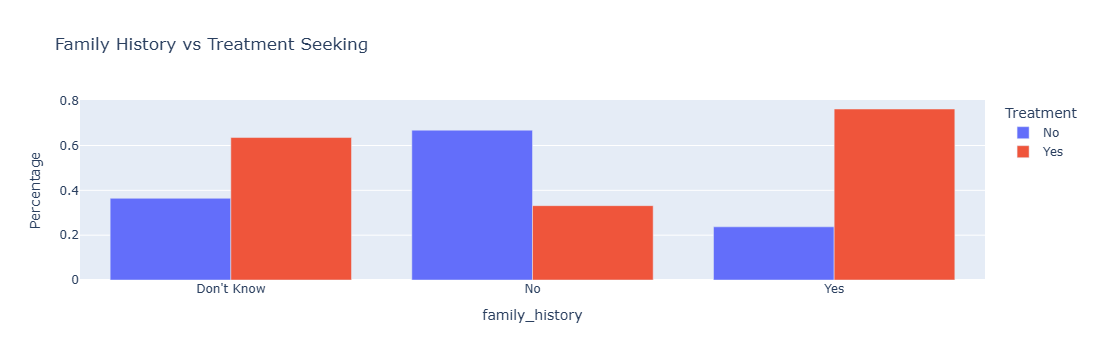

In [17]:
cross = pd.crosstab(
    df["family_history"],
    df["sought_treatment"],
    normalize="index"
)

cross = (
    cross.reset_index()
         .melt(
             id_vars="family_history",
             var_name="Treatment",
             value_name="Percentage"
         )
)

fig = px.bar(
    cross,
    x="family_history",
    y="Percentage",
    color="Treatment",
    barmode="group",
    title="Family History vs Treatment Seeking"
)

fig.show()